=== Sales by Product ===
  product  total_qty   revenue
0  Laptop         24  23999.76
1   Phone         51  35699.49
2  Tablet         24   9599.76

=== Overall Totals ===
   overall_qty  overall_revenue
0           99         69299.01


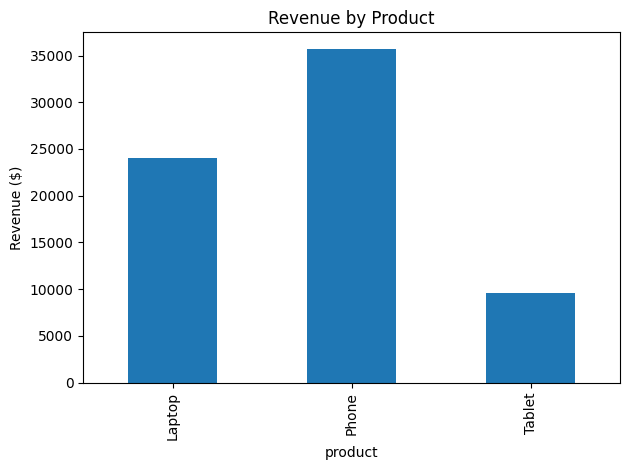

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Connect to the database
conn = sqlite3.connect('sales_data.db')

# Step 2: Run SQL queries
# Query 1: Total quantity and revenue by product
query1 = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Query 2: Overall totals (optional)
query2 = """
SELECT 
    SUM(quantity) AS overall_qty,
    SUM(quantity * price) AS overall_revenue
FROM sales
"""

# Step 3: Load data into pandas
df_products = pd.read_sql_query(query1, conn)
df_totals = pd.read_sql_query(query2, conn)

# Step 4: Display results
print("=== Sales by Product ===")
print(df_products)
print("\n=== Overall Totals ===")
print(df_totals)

# Step 5: Create visualization
# Bar chart for revenue by product
df_products.plot(kind='bar', x='product', y='revenue', 
                 title='Revenue by Product', legend=False)
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('sales_chart.png')  # Save the chart
plt.show()  # Display the chart

# Step 6: Close the connection
conn.close()